# **PROBLEM STATEMENT**

The goal of this project is to predict the **category assigned to each comment** using text and metadata signals from the platform.

**Aim:**
To train a robust model on `train.csv` and generate high-quality predictions for `test.csv`, with primary focus on **F1 Macro** performance.

The workflow follows:
- data loading and EDA
- feature engineering
- sparse text + numeric modeling
- ensemble evaluation and final submission

# IMPORT FREQUENTLY USED LIBRARIES

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")


# DATA LOADING

In [2]:
train_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 80)

In [3]:
train_data.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train_data.shape

(198000, 15)

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [6]:
train_data.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# EXPLORATORY DATA ANALYSIS

In [7]:
# check for missing values
print('Missing values in train:')
print(train_data.isnull().sum())
print()
print('Missing values in test:')
print(test_data.isnull().sum())

Missing values in train:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Missing values in test:
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


Label distribution:
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

Label percentages:
label
0    57.66
1     8.04
2    31.54
3     2.76
Name: proportion, dtype: float64


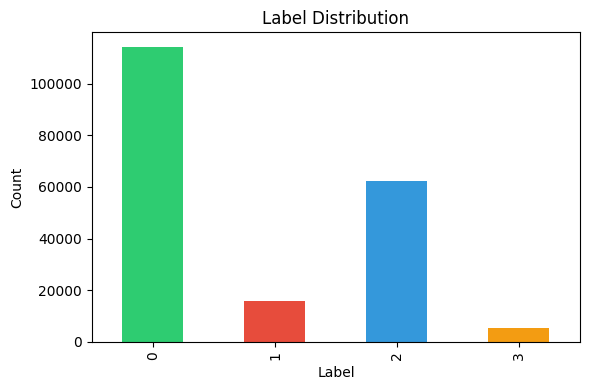

In [8]:
# target distribution
print('Label distribution:')
print(train_data['label'].value_counts().sort_index())
print()
print('Label percentages:')
print((train_data['label'].value_counts(normalize=True).sort_index() * 100).round(2))

plt.figure(figsize=(6, 4))
train_data['label'].value_counts().sort_index().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* The dataset is **imbalanced** - label 0 dominates with ~57%, while label 3 is the rarest at ~2.8%.
* This imbalance needs to be handled carefully during modeling (using class_weight, oversampling, etc.)

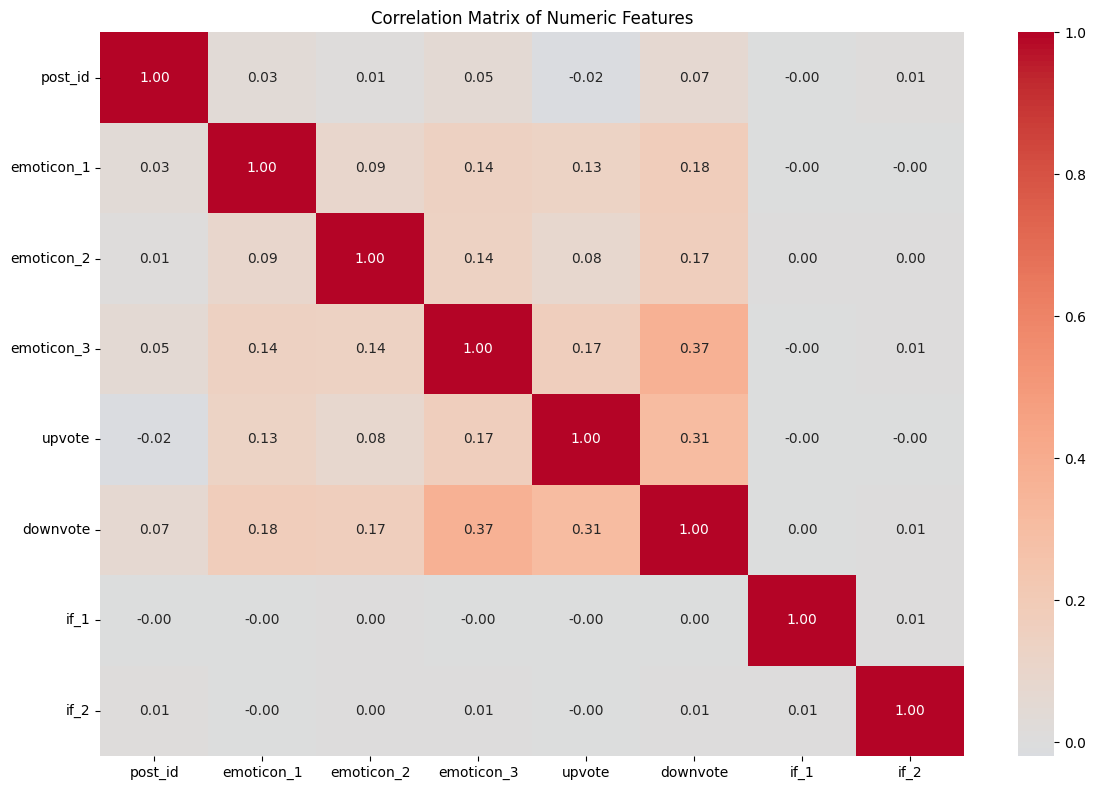

In [9]:
# correlation between numeric features
numeric_features = train_data.select_dtypes(include=[np.number]).drop(columns=['label'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

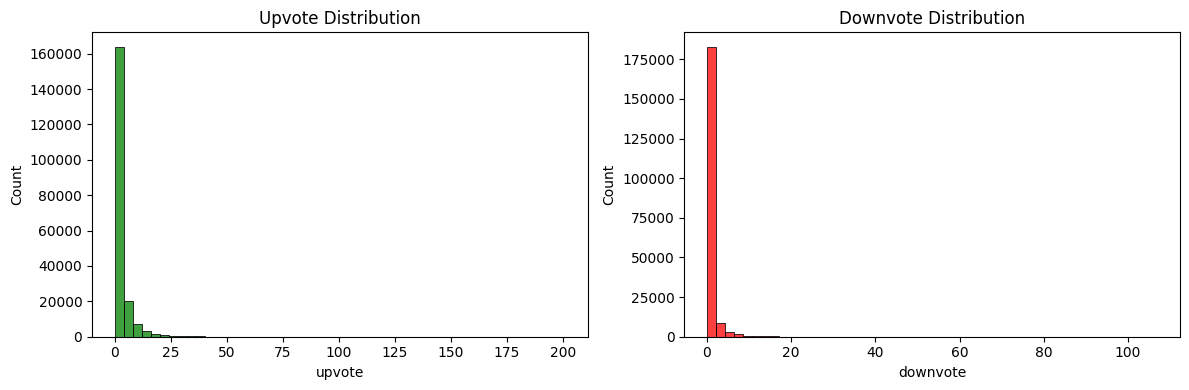

In [10]:
# distribution of upvotes and downvotes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_data['upvote'], bins=50, ax=axes[0], color='green')
axes[0].set_title('Upvote Distribution')
sns.histplot(train_data['downvote'], bins=50, ax=axes[1], color='red')
axes[1].set_title('Downvote Distribution')
plt.tight_layout()
plt.show()

---
Additional EDA plots to better understand the data distribution.


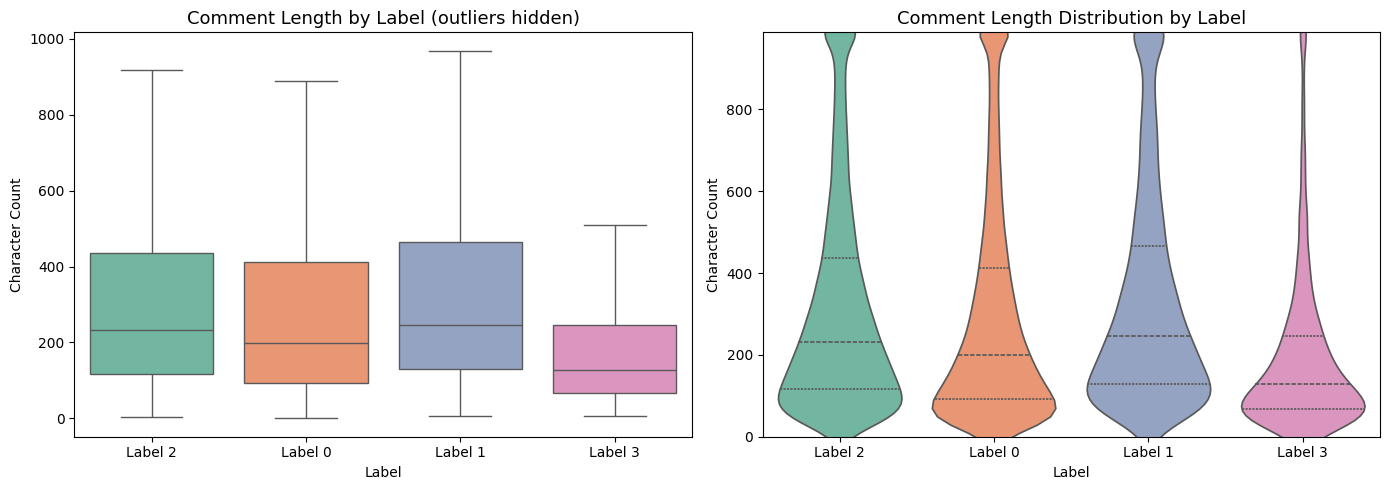

In [11]:
# comment length varies quite a bit across categories — worth visualising
train_data["comment_len_tmp"] = train_data["comment"].fillna("").str.len()

label_names = {0: "Label 0", 1: "Label 1", 2: "Label 2", 3: "Label 3"}
plot_df = train_data[["comment_len_tmp", "label"]].copy()
plot_df["label"] = plot_df["label"].map(label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot — shows spread and outliers per label
sns.boxplot(
    data=plot_df, x="label", y="comment_len_tmp",
    palette="Set2", showfliers=False, ax=axes[0]
)
axes[0].set_title("Comment Length by Label (outliers hidden)", fontsize=13)
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Character Count")

# violin — shows full distribution shape
sns.violinplot(
    data=plot_df, x="label", y="comment_len_tmp",
    palette="Set2", inner="quartile", ax=axes[1]
)
axes[1].set_title("Comment Length Distribution by Label", fontsize=13)
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Character Count")
axes[1].set_ylim(0, plot_df["comment_len_tmp"].quantile(0.97))

plt.tight_layout()
plt.show()

train_data.drop(columns=["comment_len_tmp"], inplace=True)


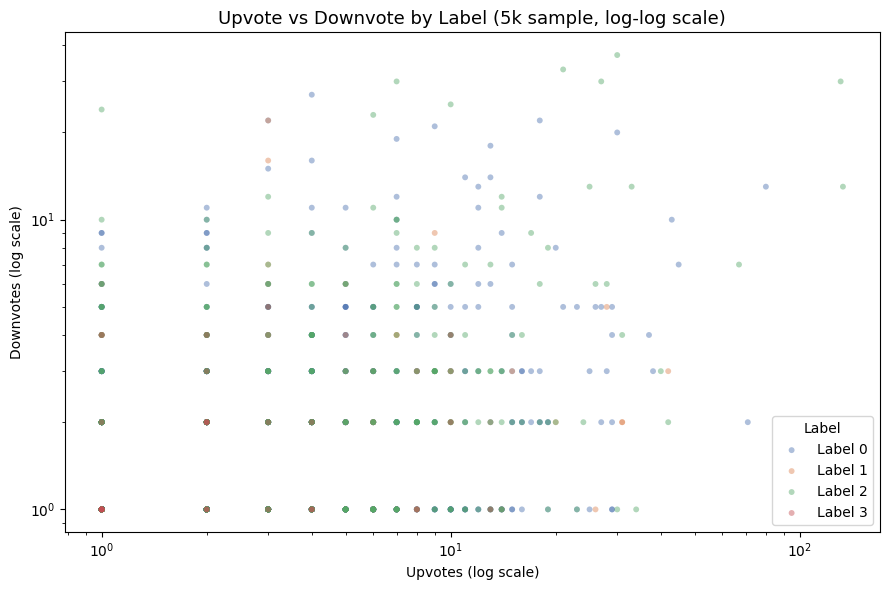

In [12]:
# scatter: upvotes vs downvotes, coloured by label
# sample 5k rows so the plot stays readable
sample = train_data.sample(n=min(5000, len(train_data)), random_state=7)

palette = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868", 3: "#C44E52"}

plt.figure(figsize=(9, 6))
for lbl, grp in sample.groupby("label"):
    plt.scatter(
        grp["upvote"], grp["downvote"],
        label=f"Label {lbl}", alpha=0.45, s=18,
        color=palette[lbl], edgecolors="none"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Upvotes (log scale)")
plt.ylabel("Downvotes (log scale)")
plt.title("Upvote vs Downvote by Label (5k sample, log-log scale)", fontsize=13)
plt.legend(title="Label")
plt.tight_layout()
plt.show()


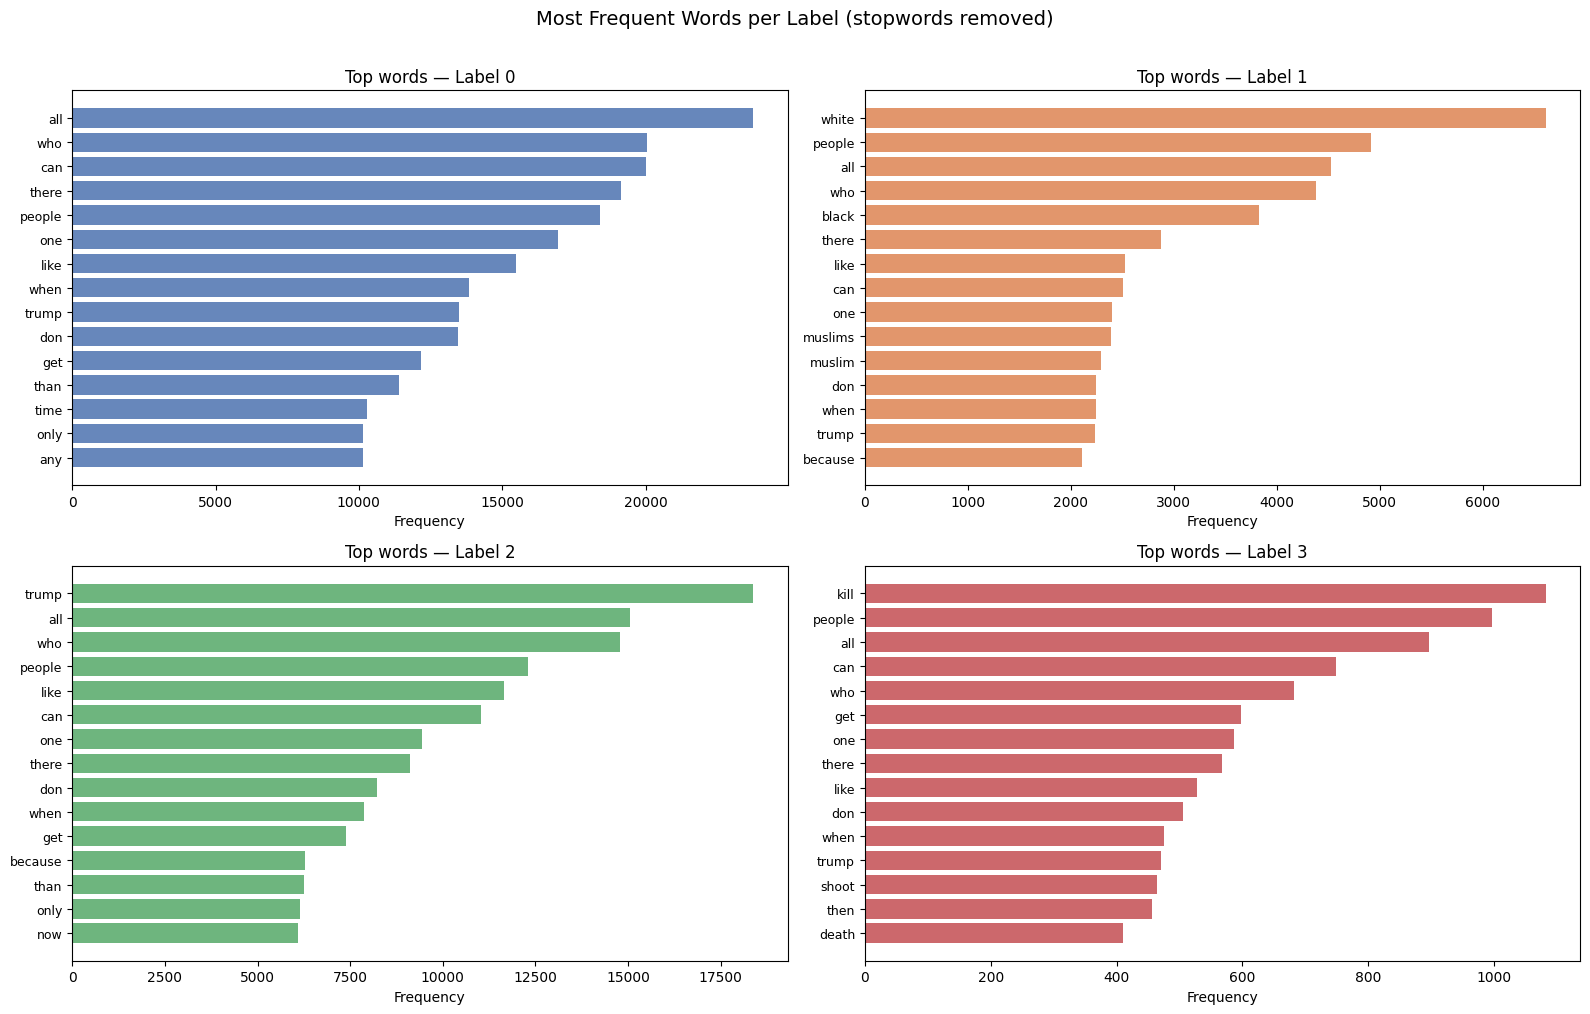

In [13]:
# top words per label — gives a quick feel for what each class is about
from collections import Counter
import re as _re

stopwords = {
    "the","a","an","and","or","but","in","on","at","to","for","of","with",
    "is","it","its","this","that","are","was","were","be","been","have",
    "has","had","do","does","did","will","would","could","should","i",
    "he","she","they","we","you","my","your","his","her","their","our",
    "me","him","us","them","what","how","if","so","just","not","no","s",
    "t","re","ve","ll","d","m","from","by","as","up","out","about","more",
}

def top_words(texts, n=15):
    words = []
    for t in texts:
        words += [w for w in _re.findall(r"[a-z]+", str(t).lower()) if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for lbl, ax, color in zip(range(4), axes.flat, colors):
    subset = train_data[train_data["label"] == lbl]["comment"]
    pairs  = top_words(subset)
    words, counts = zip(*pairs)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top words — Label {lbl}", fontsize=12)
    ax.set_xlabel("Frequency")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Most Frequent Words per Label (stopwords removed)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# FEATURE ENGINEERING

We create new features from the existing columns to give the models more signal:
1. **Text-based features** from the comment column (length, word count, caps ratio, special chars)
2. **Date-based features** extracted from created_date (hour, day of week, month, weekend flag)
3. **Interaction features** combining related columns (vote difference, emoticon sum, identity sum)

In [14]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s!?.,\'\"\\-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def encode_categorical_columns(df):
    # race, religion, gender, disability arrive as object/bool dtype
    # map each to 0/1 so models receive clean numeric flags
    identity_cols = ["race", "religion", "gender", "disability"]
    truthy = {"true", "1", "1.0"}
    for col in identity_cols:
        if col not in df.columns:
            continue
        df[col] = df[col].map(lambda x: 1 if str(x).lower() in truthy else 0)
    return df


def coerce_numeric_columns(df):
    for col in ["upvote", "downvote", "emoticon_1", "emoticon_2", "emoticon_3",
                "if_1", "if_2"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    return df


### Feature helper blocks
To keep this section readable, feature creation is split into small helper functions.

In [15]:
def add_text_features(df):
    df['comment_length'] = df['comment'].str.len()
    df['word_count'] = df['comment'].str.split().str.len().fillna(0).astype(int)
    df['avg_word_length'] = df['comment_length'] / (df['word_count'] + 1)
    df['uppercase_ratio'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['special_char_count'] = df['comment'].apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))
    df['exclamation_count'] = df['comment'].str.count('!')
    df['question_count'] = df['comment'].str.count(r'\?')
    df['digit_ratio'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isdigit()) / (len(x) + 1))
    df['sentence_count'] = df['comment'].apply(lambda x: max(1, len(re.split(r'[.!?]+', x)) - 1) if x else 0)
    df['unique_word_ratio'] = df['comment'].apply(
        lambda x: len(set(x.lower().split())) / (len(x.lower().split()) + 1) if x else 0
    )
    return df

In [16]:
def engineer_features(df):
    df = df.copy()
    df["comment"] = df["comment"].fillna("")
    df["comment_clean"] = df["comment"].apply(clean_text)
    df = encode_categorical_columns(df)  # encode race/religion/gender/disability to 0/1
    df = coerce_numeric_columns(df)
    df = add_text_features(df)
    df = add_date_features(df)
    df = add_interaction_features(df)
    return df


In [17]:
def add_interaction_features(df):
    df['vote_diff'] = df['upvote'] - df['downvote']
    df['vote_total'] = df['upvote'] + df['downvote']
    df['vote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['identity_sum'] = df['race'] + df['religion'] + df['gender'] + df['disability']
    df['has_identity'] = (df['identity_sum'] > 0).astype(int)
    df['if_sum'] = df['if_1'] + df['if_2']
    df['if_product'] = df['if_1'] * df['if_2']
    df['if_ratio'] = df['if_1'] / (df['if_2'] + 1)
    df['log_upvote'] = np.log1p(df['upvote'])
    df['log_downvote'] = np.log1p(df['downvote'])
    df['log_if_1'] = np.log1p(df['if_1'])
    df['log_if_2'] = np.log1p(df['if_2'])
    df['log_comment_length'] = np.log1p(df['comment_length'])
    return df

In [18]:
def add_date_features(df):
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
    df['hour'] = df['created_date'].dt.hour.fillna(0).astype(int)
    df['day_of_week'] = df['created_date'].dt.dayofweek.fillna(0).astype(int)
    df['month'] = df['created_date'].dt.month.fillna(0).astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['year'] = df['created_date'].dt.year.fillna(0).astype(int)
    return df

In [19]:
train_data = engineer_features(train_data)
test_data = engineer_features(test_data)

print('After feature engineering:')
print('Train:', train_data.shape)
print('Test:', test_data.shape)

After feature engineering:
Train: (198000, 45)
Test: (102000, 44)


### Feature engineering status
Both train and test sets now have the engineered columns and cleaned text fields ready for preprocessing.

# DATA PREPROCESSING

In [20]:
numeric_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote',
    'if_1', 'if_2', 'race', 'religion', 'gender', 'disability',
    'post_id',
    'comment_length', 'word_count', 'avg_word_length', 'uppercase_ratio',
    'special_char_count', 'exclamation_count', 'question_count',
    'digit_ratio', 'sentence_count', 'unique_word_ratio',
    'hour', 'day_of_week', 'month', 'is_weekend', 'year',
    'vote_diff', 'vote_total', 'vote_ratio', 'emoticon_sum',
    'identity_sum', 'has_identity', 'if_sum', 'if_product', 'if_ratio',
    'log_upvote', 'log_downvote', 'log_if_1', 'log_if_2', 'log_comment_length'
]

print(f'Numeric features selected: {len(numeric_cols)}')

Numeric features selected: 41


In [21]:
train_data[numeric_cols] = train_data[numeric_cols].fillna(0)
test_data[numeric_cols] = test_data[numeric_cols].fillna(0)
y = train_data['label'].values

print('Train rows:', len(train_data), '| Test rows:', len(test_data))

Train rows: 198000 | Test rows: 102000


### Text vectorization (word + char TF-IDF)
Use both word-level and character-level features for stronger robustness.

In [22]:
# Word TF-IDF
print('Fitting Word TF-IDF...')
tfidf_word = TfidfVectorizer(
    max_features=40000, ngram_range=(1, 2),
    min_df=2, max_df=0.95, sublinear_tf=True,
    strip_accents='unicode', analyzer='word'
)
X_tfidf_word_train = tfidf_word.fit_transform(train_data['comment_clean'])
X_tfidf_word_test = tfidf_word.transform(test_data['comment_clean'])
print('  Word TF-IDF:', X_tfidf_word_train.shape)

# Character TF-IDF
print('Fitting Char TF-IDF...')
tfidf_char = TfidfVectorizer(
    max_features=25000, ngram_range=(2, 5),
    min_df=3, max_df=0.9, sublinear_tf=True,
    analyzer='char_wb'
)
X_tfidf_char_train = tfidf_char.fit_transform(train_data['comment_clean'])
X_tfidf_char_test = tfidf_char.transform(test_data['comment_clean'])
print('  Char TF-IDF:', X_tfidf_char_train.shape)

Fitting Word TF-IDF...
  Word TF-IDF: (198000, 40000)
Fitting Char TF-IDF...
  Char TF-IDF: (198000, 25000)


### Build final sparse matrix and split
Scale numeric features, stack with TF-IDF, then create train/validation sets.

In [23]:
scaler = StandardScaler()
X_num_train = csr_matrix(scaler.fit_transform(train_data[numeric_cols]))
X_num_test = csr_matrix(scaler.transform(test_data[numeric_cols]))

X_all = hstack([X_tfidf_word_train, X_tfidf_char_train, X_num_train])
X_test_full = hstack([X_tfidf_word_test, X_tfidf_char_test, X_num_test])
print('Combined shape:', X_all.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.15, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Val:', X_val.shape)

Combined shape: (198000, 65041)
Train: (168300, 65041) | Val: (29700, 65041)


# MODEL TRAINING AND EVALUATION

### LightGBM baseline on sparse features
This is the main high-capacity model trained directly on TF-IDF + numeric sparse matrix.

In [24]:
results = {}  # will hold val metrics for each model


In [25]:
# LightGBM setup
print('Preparing LightGBM datasets and parameters...')

lgb_train_set = lgb.Dataset(X_train, label=y_train)
lgb_val_set = lgb.Dataset(X_val, label=y_val, reference=lgb_train_set)

lgb_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'learning_rate': 0.06,
    'num_leaves': 95,
    'max_depth': 9,
    'min_child_samples': 40,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.75,
    'bagging_freq': 5,
    'lambda_l1': 0.3,
    'lambda_l2': 0.8,
    'min_gain_to_split': 0.02,
    'is_unbalance': True,
    'n_jobs': -1,
    'verbose': -1,
    'seed': 42,
}

callbacks = [lgb.log_evaluation(50), lgb.early_stopping(80)]

Preparing LightGBM datasets and parameters...


In [26]:
# LightGBM training
print('Training LightGBM...')
lgb_model = lgb.train(
    lgb_params, lgb_train_set,
    num_boost_round=2000,
    valid_sets=[lgb_val_set],
    callbacks=callbacks
)

lgb_proba_val = lgb_model.predict(X_val)
lgb_preds_val = lgb_proba_val.argmax(axis=1)

Training LightGBM...
Training until validation scores don't improve for 80 rounds
[50]	valid_0's multi_logloss: 0.300819
[100]	valid_0's multi_logloss: 0.274624
[150]	valid_0's multi_logloss: 0.264625
[200]	valid_0's multi_logloss: 0.258893
[250]	valid_0's multi_logloss: 0.254928
[300]	valid_0's multi_logloss: 0.252388
[350]	valid_0's multi_logloss: 0.250461
[400]	valid_0's multi_logloss: 0.249372
[450]	valid_0's multi_logloss: 0.248618
[500]	valid_0's multi_logloss: 0.247905
[550]	valid_0's multi_logloss: 0.247332
[600]	valid_0's multi_logloss: 0.247006
[650]	valid_0's multi_logloss: 0.246732
[700]	valid_0's multi_logloss: 0.246684
[750]	valid_0's multi_logloss: 0.246838
[800]	valid_0's multi_logloss: 0.247021
Early stopping, best iteration is:
[721]	valid_0's multi_logloss: 0.24656


In [27]:
# LightGBM evaluation
lgb_acc = accuracy_score(y_val, lgb_preds_val)
lgb_f1 = f1_score(y_val, lgb_preds_val, average='macro')
print(f'\nLightGBM  —  Accuracy: {lgb_acc:.5f} | F1 Macro: {lgb_f1:.5f}')
print(classification_report(y_val, lgb_preds_val))
results['LightGBM'] = {'accuracy': lgb_acc, 'f1_macro': lgb_f1}


LightGBM  —  Accuracy: 0.91663 | F1 Macro: 0.81221
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.80      0.76      0.78      2388
           2       0.85      0.93      0.89      9366
           3       0.78      0.51      0.62       820

    accuracy                           0.92     29700
   macro avg       0.85      0.79      0.81     29700
weighted avg       0.92      0.92      0.92     29700



### Logistic Regression baseline
A fast linear baseline with balanced class weight for macro-F1.

In [28]:
# Hyperparameter tuning for Logistic Regression
# GridSearchCV over C (regularization strength) and solver, 3-fold, scored on F1 Macro
# Pipeline wraps scaler + classifier so preprocessing is reproducible and
# stays encapsulated - param_grid uses 'clf__' prefix to reach Pipeline steps
print("Tuning Logistic Regression with GridSearchCV...")

param_grid = {
    "clf__C":      [0.1, 0.5, 1.0, 5.0, 10.0],
    "clf__solver": ["lbfgs", "saga", "liblinear"]
}
lr_pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("clf", LogisticRegression(
        max_iter=500, class_weight="balanced", n_jobs=-1, random_state=42
    ))
])
lr_cv = GridSearchCV(lr_pipeline, param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=0)
lr_cv.fit(X_train, y_train)

best_C      = lr_cv.best_params_["clf__C"]
best_solver = lr_cv.best_params_["clf__solver"]
print(f"Best C: {best_C}  |  Best solver: {best_solver}  |  Mean CV F1: {lr_cv.best_score_:.5f}")
lr_model = lr_cv.best_estimator_

Tuning Logistic Regression with GridSearchCV...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/s

Best C: 0.1  |  Best solver: liblinear  |  Mean CV F1: 0.80440


In [29]:
# lr_model is already fitted on X_train by GridSearchCV (refit=True by default)
lr_proba_val = lr_model.predict_proba(X_val)
lr_preds_val = lr_proba_val.argmax(axis=1)


In [30]:
# Logistic Regression evaluation
lr_acc = accuracy_score(y_val, lr_preds_val)
lr_f1 = f1_score(y_val, lr_preds_val, average='macro')
print(f'LogisticReg  —  Accuracy: {lr_acc:.5f} | F1 Macro: {lr_f1:.5f}')
print(classification_report(y_val, lr_preds_val))
results['LogisticReg'] = {'accuracy': lr_acc, 'f1_macro': lr_f1}

LogisticReg  —  Accuracy: 0.90680 | F1 Macro: 0.81432
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     17126
           1       0.71      0.82      0.76      2388
           2       0.87      0.90      0.89      9366
           3       0.60      0.72      0.65       820

    accuracy                           0.91     29700
   macro avg       0.79      0.84      0.81     29700
weighted avg       0.91      0.91      0.91     29700



### SGDClassifier via sklearn Pipeline (3rd model)
SGD with `modified_huber` loss is well-suited for sparse TF-IDF data and supports
`predict_proba`, which we need for soft-voting. Wrapping it in a `Pipeline` with
`MaxAbsScaler` keeps the sparse structure intact and makes the preprocessing reproducible.


In [31]:
# 3rd model: SGDClassifier wrapped in a sklearn Pipeline
# MaxAbsScaler preserves sparsity; modified_huber gives calibrated probabilities
sgd_pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("clf", SGDClassifier(
        loss="modified_huber", penalty="l2", alpha=1e-4,
        class_weight="balanced", max_iter=200, tol=1e-3,
        random_state=42, n_jobs=-1
    ))
])

print("Training SGDClassifier pipeline...")
sgd_pipeline.fit(X_train, y_train)

sgd_proba_val = sgd_pipeline.predict_proba(X_val)
sgd_preds_val = sgd_proba_val.argmax(axis=1)


Training SGDClassifier pipeline...


In [32]:
# SGDClassifier evaluation
sgd_acc = accuracy_score(y_val, sgd_preds_val)
sgd_f1  = f1_score(y_val, sgd_preds_val, average="macro")
print(f"SGDClassifier  —  Accuracy: {sgd_acc:.5f} | F1 Macro: {sgd_f1:.5f}")
print(classification_report(y_val, sgd_preds_val))
results["SGDClassifier"] = {"accuracy": sgd_acc, "f1_macro": sgd_f1}


SGDClassifier  —  Accuracy: 0.90017 | F1 Macro: 0.79292
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     17126
           1       0.70      0.80      0.75      2388
           2       0.86      0.89      0.88      9366
           3       0.61      0.59      0.60       820

    accuracy                           0.90     29700
   macro avg       0.78      0.80      0.79     29700
weighted avg       0.90      0.90      0.90     29700



### Optimized weighted ensemble
Instead of fixed 0.6/0.4, search the best LightGBM weight on validation F1 Macro.

In [33]:
# Ensemble weight search over LGB / LR / SGD
# We do a grid over w_lgb and w_lr; w_sgd = 1 - w_lgb - w_lr
print("Searching best ensemble weights (LGB + LR + SGD)...")
print()

import numpy as np
best_w_lgb, best_w_lr, best_w_sgd = 0.6, 0.3, 0.1
best_f1  = 0
best_acc = 0

for w_lgb in np.arange(0.0, 1.01, 0.02):
    for w_lr in np.arange(0.0, round(1.01 - w_lgb, 4), 0.02):
        w_sgd = round(1.0 - w_lgb - w_lr, 4)
        if w_sgd < 0:
            continue
        ens = w_lgb * lgb_proba_val + w_lr * lr_proba_val + w_sgd * sgd_proba_val
        preds = ens.argmax(axis=1)
        f1  = f1_score(y_val, preds, average="macro")
        acc = accuracy_score(y_val, preds)
        if f1 > best_f1:
            best_f1, best_acc = f1, acc
            best_w_lgb, best_w_lr, best_w_sgd = w_lgb, w_lr, w_sgd

results["Ensemble"] = {"accuracy": best_acc, "f1_macro": best_f1}
print(f"Best weights - LGB: {best_w_lgb:.2f}, LR: {best_w_lr:.2f}, SGD: {best_w_sgd:.2f}")
print(f"Ensemble F1 Macro: {best_f1:.5f}")

Searching best ensemble weights (LGB + LR + SGD)...

Best weights - LGB: 0.36, LR: 0.64, SGD: 0.00
Ensemble F1 Macro: 0.83404


In [34]:
# Final comparison summary
print(f"Best weights — LGB: {best_w_lgb:.2f}, LR: {best_w_lr:.2f}, SGD: {best_w_sgd:.2f}")
print()
print("--- Per-model breakdown ---")
print(f"LGB alone       — Acc: {lgb_acc:.5f} | F1: {lgb_f1:.5f}")
print(f"LR alone        — Acc: {lr_acc:.5f} | F1: {lr_f1:.5f}")
print(f"SGD alone       — Acc: {sgd_acc:.5f} | F1: {sgd_f1:.5f}")
print(f"Ensemble (3)    — Acc: {best_acc:.5f} | F1: {best_f1:.5f}")


Best weights — LGB: 0.36, LR: 0.64, SGD: 0.00

--- Per-model breakdown ---
LGB alone       — Acc: 0.91663 | F1: 0.81221
LR alone        — Acc: 0.90680 | F1: 0.81432
SGD alone       — Acc: 0.90017 | F1: 0.79292
Ensemble (3)    — Acc: 0.91902 | F1: 0.83404


# MODEL COMPARISON

               accuracy  f1_macro
Ensemble       0.919024  0.834043
LogisticReg    0.906801  0.814316
LightGBM       0.916633  0.812209
SGDClassifier  0.900168  0.792923

Best model: Ensemble with F1 Macro = 0.83404


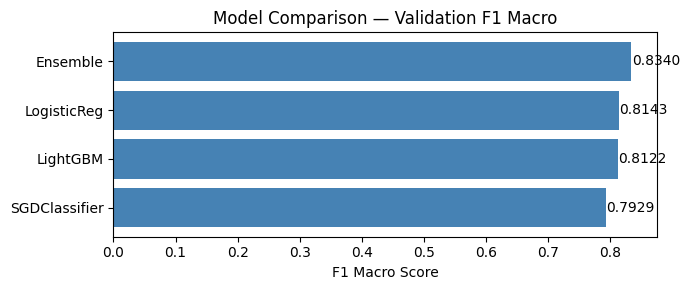

In [35]:
res_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
print(res_df.to_string())
print(f'\nBest model: {res_df.index[0]} with F1 Macro = {res_df.iloc[0]["f1_macro"]:.5f}')

plt.figure(figsize=(7, 3))
plt.barh(res_df.index[::-1], res_df['f1_macro'][::-1], color='steelblue')
for i, (name, row) in enumerate(res_df[::-1].iterrows()):
    plt.text(row['f1_macro'] + 0.001, i, f'{row["f1_macro"]:.4f}', va='center')
plt.xlabel('F1 Macro Score')
plt.title('Model Comparison — Validation F1 Macro')
plt.tight_layout()
plt.show()


Based on validation F1 Macro, we select the strongest-performing setup and use the same strategy for final test prediction export.

# FINAL SUBMISSION

For submission, I retrain both models on full data and then blend test probabilities with the optimized validation weight.

In [36]:
# Retrain all three models on the full training data
lgb_full  = lgb.Dataset(X_all, label=y)
lgb_final = lgb.train(
    lgb_params, lgb_full,
    num_boost_round=lgb_model.best_iteration + 50,
    callbacks=[lgb.log_evaluation(100)]
)
print("LightGBM retrained.")

# Use a Pipeline for final LR retraining (consistent with tuning pipeline)
lr_final = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("clf", LogisticRegression(
        C=best_C, solver=best_solver, max_iter=500,
        class_weight="balanced", n_jobs=-1, random_state=42
    ))
])
lr_final.fit(X_all, y)
print("LogisticReg retrained.")

sgd_final = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("clf", SGDClassifier(
        loss="modified_huber", penalty="l2", alpha=1e-4,
        class_weight="balanced", max_iter=200, tol=1e-3,
        random_state=42, n_jobs=-1
    ))
])
sgd_final.fit(X_all, y)
print("SGDClassifier retrained.")

# Blend test probabilities with the best weights found on validation
test_proba = (
    best_w_lgb * lgb_final.predict(X_test_full)
    + best_w_lr  * lr_final.predict_proba(X_test_full)
    + best_w_sgd * sgd_final.predict_proba(X_test_full)
)
test_preds = test_proba.argmax(axis=1)

LightGBM retrained.
LogisticReg retrained.
SGDClassifier retrained.


In [37]:
# Build and save submission
submission = sample_data.copy()
submission['label'] = test_preds
submission.to_csv('submission.csv', index=False)

print('Submission saved as submission.csv')
print('Shape:', submission.shape)
print('\nPrediction distribution:')
print(submission['label'].value_counts().sort_index())
print(f'\nExpected Kaggle F1 Macro: ~{best_f1:.5f} (based on val)')
submission.head(10)

Submission saved as submission.csv
Shape: (102000, 2)

Prediction distribution:
label
0    56632
1     8454
2    34417
3     2497
Name: count, dtype: int64

Expected Kaggle F1 Macro: ~0.83404 (based on val)


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2
